# s2 — Minimal alpha example

End-to-end run of the `src.alphas` framework on the SP500 panel: load data, build the data package, compute the `OvernightZScore` signal, and plot a simple equal-weighted cumulative PnL.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.alphas.data import DataCol
from src.alphas.panel import build_data_package
from src.alphas.signals import OvernightZScore

In [2]:
PANEL = ROOT / 'data' / 'processed' / 'ohlcv_long.parquet'
df = pd.read_parquet(PANEL)
print(df.shape, '|', df['ticker'].nunique(), 'tickers |',
      df['date'].min().date(), '→', df['date'].max().date())

(3681710, 8) | 682 tickers | 2000-01-03 → 2026-04-21


## Build the data package

`build_data_package` pivots the long panel into `{DataCol: wide DataFrame}`. Request every column the alpha needs (plus `DAY_RETURN` here so we can score PnL).

In [3]:
data = build_data_package(df, cols=[DataCol.OVN_RETURN, DataCol.DAY_RETURN])
data[DataCol.OVN_RETURN].tail()

ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2026-04-15,0.000083,-0.000278,0.009893,-0.006427,-0.002589,-0.006040,0.004931,0.0,-0.002771,-0.001975,...,-0.004288,-0.006547,0.007092,-0.003162,0.012850,-0.003218,-0.002383,0.000265,0.003728,0.005202
2026-04-16,0.002171,0.006962,0.015612,-0.005802,0.001389,-0.003071,0.009890,0.0,-0.043620,-0.003693,...,0.003490,-0.010788,0.006803,-0.001837,0.007209,-0.002841,0.002548,0.003135,-0.002102,0.001076
2026-04-17,0.010317,-0.076197,0.072535,0.017473,0.013516,0.003206,0.015202,0.0,0.001571,-0.004016,...,-0.046848,0.023160,0.037267,-0.035221,0.019951,0.001066,-0.000317,0.018967,0.011050,0.008737
2026-04-20,-0.006564,0.008991,-0.031299,0.001392,0.000370,-0.002112,-0.003886,0.0,-0.003202,-0.001435,...,0.006419,-0.007994,-0.005780,-0.004872,-0.003087,0.005406,-0.003904,-0.004394,-0.006695,-0.006782
2026-04-21,0.004878,0.001954,-0.015114,-0.000349,-0.005878,0.001473,0.002020,0.0,-0.004167,0.008616,...,-0.002099,0.006255,0.005405,-0.014860,0.002842,-0.001112,0.000943,0.007248,-0.005551,-0.005867


## Run the alpha

Instantiate and call it — the base class checks declared dependencies and filters the package down before handing it to `calc`.

In [6]:
alpha = OvernightZScore(period=30, threshold=2.0)
signal = alpha(data)
signal.tail()

ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2026-04-15,0.230163,0.054236,0.866026,-0.201230,-0.035303,-0.461731,0.041969,1.652794e-26,-0.186788,-0.775342,...,-0.411158,0.325600,0.295452,0.029207,0.122585,-0.310931,0.024548,0.282695,-0.011315,-0.176772
2026-04-16,-0.004527,-0.083783,0.045851,-0.210584,-0.210787,-0.313551,0.148845,1.598590e-26,-0.173141,-0.069433,...,-0.066176,-0.207735,0.259476,-0.099804,0.192412,-0.224577,-0.150752,-0.012758,0.147349,0.345783
2026-04-17,0.104109,0.057242,0.117230,-0.183357,0.057574,-0.113111,0.296724,1.546162e-26,-1.000000,-0.214557,...,0.147815,-0.302982,0.239963,-0.044866,0.072293,-0.188868,0.170759,0.055729,-0.092719,0.093916
2026-04-20,0.517362,-1.000000,0.784665,0.542268,0.796085,0.300999,0.445038,1.495455e-26,0.166437,-0.234394,...,-1.000000,0.548246,1.000000,-1.000000,0.330141,0.108265,-0.024609,0.430161,0.445380,0.529273
2026-04-21,-0.391867,0.155446,-0.507082,0.015849,-0.065720,-0.067056,-0.186371,1.446410e-26,-0.020511,0.008873,...,0.260339,-0.253399,-0.213418,-0.063140,-0.168502,0.427008,-0.266752,-0.159587,-0.307807,-0.404422


## Equal-weighted PnL

Normalise by number of names and multiply by next-day return. Signal is already shifted inside the alpha, so we pair it with the contemporaneous `DAY_RETURN`.

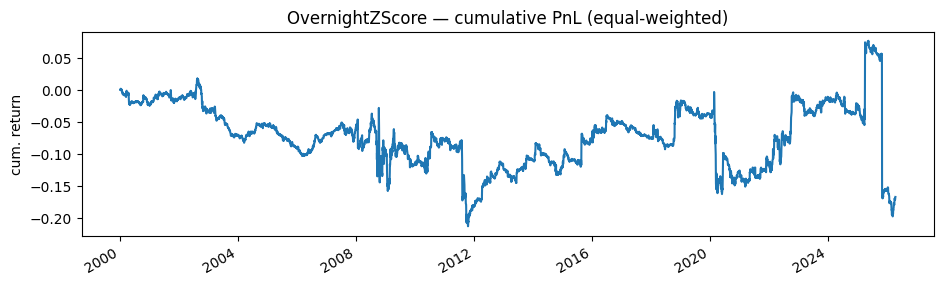

In [7]:
day_ret = data[DataCol.DAY_RETURN]
weights = signal / signal.shape[1]
pnl = weights.mul(day_ret).sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 3))
pnl.cumsum().plot(ax=ax, title='OvernightZScore — cumulative PnL (equal-weighted)')
ax.set_xlabel('')
ax.set_ylabel('cum. return');